# Fourier Transform Demo: Periodic Neural Dynamics

This notebook walks through a simple example of applying the Fourier transform to calcium imaging data.
The goal is to show how stimulus-driven neuronal responses can be identified at a stimulus-locked frequency, along with brief analysis of the result. If you are unfamiliar with Fourier Transformation, you could check the Intro_Fourier_Transformation notebook, where I introduce basic concept of Fourier Transformation

The dataset in `/data` serves as an example; in practice, the same pipeline can be applied to other experimental recordings with slight variation.

The calcium imaging data comes from zebrafish performing phototaxis, the tendency of zebrafish to orient toward illumination. Phototaxis behavior was elicited in this dataset by a periodic half-field dark stimulus (more detail can be found in [original Neuron paper](<https://www.cell.com/neuron/pdf/S0896-6273(18)30844-4.pdf>)). The periodicity of the stimulus makes it suitable for Fourier analysis.


# Setup Instructions

This notebook is self-contained and will help you set up everything needed.

**How to use:**
1. Create a project folder on your computer, with:
   - a `data/` folder for datasets
   - a `notebooks/` folder for this notebook
2. Open a terminal in the project folder.
3. Create and activate a virtual environment.
4. Install dependencies.
5. Launch Jupyter Notebook and open this file.

No prior setup is required beyond having Python installed.


In [ ]:
# Step 1) Navigate to the project folder
cd path\to\your\project

# Step 2) Create a new environment named venv
python -m venv venv

# Step 3) Activate the environment
# PowerShell:
.\venv\Scripts\Activate.ps1
# Or in Command Prompt (cmd.exe):
venv\Scripts\activate.bat

# Step 4) Install the required dependencies
pip install -r requirements.txt

# Step 5) Launch Jupyter Notebook
python -m jupyter notebook


### Next steps inside Jupyter
- In the browser window that opens, navigate to the `notebooks/` folder.
- Open `Notebook_01.ipynb`.
- Ensure the kernel is set to the environment you just created (look for `(venv)` in the kernel name).
- Run the cells step by step to reproduce the analysis.

The next block fetch the directory, please check if the path for Project roots and Data folder are correct

In [2]:
# Import required dependencies
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import h5py
import scipy

# Get the project root (assume the notebook lives inside /notebooks)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Define data folder
DATA_DIR = PROJECT_ROOT / "data"

print("Project root:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)

# Check that the folder exists
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"❌ Data folder not found at {DATA_DIR}. "
        "Please make sure you have a 'data' folder in your project root."
    )


Project root: /Users/jingpindanielliu/PycharmProjects/Fourier
Data folder: /Users/jingpindanielliu/PycharmProjects/Fourier/data


# Step 1: Identifying Periodic Properties in the Stimulus Signal

In this section, we analyze the **phototaxis stimulus pattern**.
Because the stimulus was designed to be periodic, we can extract key properties such as its **frequency (or wavelength)** and **phase**.

These properties serve as selection criteria for identifying neurons whose activity patterns closely match the periodic structure of the stimulus. Such neurons are referred to as **stimulus-locked neurons**, and we assume that at least a subset of them are directly involved in the sensory processing of the stimulation.

We will begin by loading the stimulus data, which can be found in the `/data/stimulus` file.



In [ ]:
# read the stimulus data
stimulus = pd.read_excel(
    DATA_DIR / "stimulus.xlsx",
    header=None
).to_numpy()[0]

# Represent left/right stimulus by box-car functions
stimulus_right = list([1 if x == 1 else 0 for x in stimulus])
stimulus_left = list([1 if x == 2 else 0 for x in stimulus])

The arrays above represent the **left- and right-sided phototaxis stimuli** as boxcar functions.
- A **right-sided phototaxis stimulus** means the **left side of the fish is dark** while the **right side is illuminated**. Conversely, a **left-sided phototaxis stimulus** means the right side is dark and the left side is illuminated.

Each array element corresponds to the **stimulus status at a given frame** (sampling rate ≈ 1.97 Hz).
- A value of **1** indicates the stimulus was present.
- A value of **0** indicates the stimulus was absent.
- Because the sampling rate is not an exact integer, we use **frame index** (rather than seconds) as the time unit for analysis.

To visualize the stimulus signal pattern for the first 500 frames as a box-car function, run the following code cell.


In [ ]:
#Visualize the stimulus signal for first 500 frames
plt.figure(figsize=(10,2))
plt.plot(stimulus_left[:500],c = "red")
plt.plot(stimulus_right[:500],c = "blue")
plt.xlabel("Frame")
plt.legend(["left", "right"])
plt.show()

![Stimulus diagram](../images/stimulus.png)

**Figure:** Schematic representation of the phototaxis stimulation provided to the fish. Dark blocks indicate a half-field dark stimulus on the corresponding side.

The stimulus paradigm is **periodic**, consisting of repeated **cycles** of **140 frames** each. Within each cycle, the fish experienced two phototaxis stimuli, each lasting **40 frames**:
- a **right-sided stimulus** from **Frame 30–70**, and
- a **left-sided stimulus** from **Frame 100–140**.

From this paradigm, we define the following criteria for identifying **stimulus-locked neurons**:
- The neuron's most dominant periodic component has a **wavelength of 140 frames** (equivalently, a **frequency of 1/140 Hz**), matching the stimulus periodicity.
- The neuron's most dominant periodic component has a **phase alignment** corresponding to the stimulus presentation windows, i.e. **Frame 30–70** (right) or **Frame 100–140** (left).


# Step 2: Identification of sensory neurons by Fourier Transformation

Now, we would like to perform **Discrete Fourier Transformation** on the neuron activity data and select neurons that matches with the selection criteria we outlined previously.

Table of content


## Step 2.1: Loading Neuron Activity Data

We begin by loading the **neuron activity data**. The example dataset used in this notebook comes from a **public zebrafish whole-brain calcium imaging dataset**. Specifically, we use **Fish_6**, which is also the example shown in the figures of the [original Neuron paper](<https://www.cell.com/neuron/pdf/S0896-6273%2818%2930844-4.pdf>).

This dataset contains activity traces from approximately **100,000 neurons** recorded over **~4,000 frames** at a sampling rate of **1.97 Hz**. Each trace represents the standardized **z-scored ΔF/F fluorescence signal** of an individual neuron.

Due to the file size, please download the raw data 'CellRespZ.h5' by running the following code cell. Or download it manually from [google drive](<https://drive.google.com/file/d/11j_hQXRwY7URa9UnZYo6vAYR5TWLgHGj/view?usp=sharing>) and put it in the `/data/` folder under the project folder



In [34]:
import gdown
dest_file = DATA_DIR / "CellRespZ.h5"

# Google Drive link
url = "https://drive.google.com/uc?export=download&id=11j_hQXRwY7URa9UnZYo6vAYR5TWLgHGj"

# Check if file already exists
if dest_file.exists():
    print(f"✅ Found dataset at {dest_file}, skipping download.")
else:
    print(f"⬇️ Downloading dataset to {dest_file} ...")
    gdown.download(url, str(dest_file), quiet=False)
    print("✅ Download complete!")

✅ Found dataset at /Users/jingpindanielliu/PycharmProjects/Fourier/data/CellRespZ.h5, skipping download.


Run the following code cell to load the neuron activity data, as well as the corresponding coordinate data.

In [35]:
with h5py.File(DATA_DIR / "CellRespZ.h5", 'r') as f:
    # Access the dataset 'CellRespZ'
    cell_resp_z = f['CellRespZ'][()]

#Read the corresponding position index
absIX = pd.read_excel(DATA_DIR /"absIX.xlsx")
absIX = absIX["neuron_index"].to_numpy().T

data = pd.read_excel(
    DATA_DIR / "CellXYZnorm.xlsx",
    header=None
).to_numpy()

coordinate = [data[i] for i in absIX][0]

print(f'The shape of loaded data is {cell_resp_z.shape},The correct shape is (92538,3780).')

The shape of loaded data is (92538, 3780),The correct shape is (92538,3780).


To make neuron indexing easier, we add a column which encodes each neuron's original index within the dataset in cell response z-score and coordinates.

Before indexing, we check the shape of neuron activity data to see if the data are loaded correctly. The neuron activity data should be an array shape (92538,3780)

Run the following code cell to add the indexing column.

In [36]:
#Add index column for each data
cell_resp_z = [[i, x] for i, x in enumerate(cell_resp_z)]
coordinate = [[i, x] for i, x in enumerate(coordinate)]

Now the neuron activity data is ready, try map a neuron trace.

Run the following code cell to map the activity of a random neuron in first 500 frames

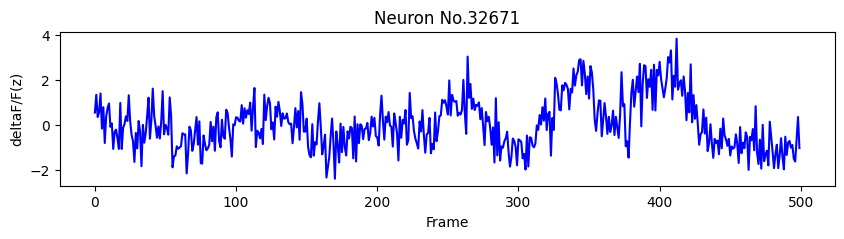

In [39]:
#Visualize a random neuron activity for first 500 frames
import random
index = random.randint(0, 92538)
plt.figure(figsize=(10,2))
plt.title(f"Neuron No.{index}")
plt.plot(cell_resp_z[index][1][:500],c = "blue")
plt.xlabel("Frame")
plt.ylabel("deltaF/F(z)")
plt.show()